# Introduction

In this project, you will build a neural network of your own design to evaluate the MNIST dataset.

Some of the benchmark results on MNIST include can be found [on Yann LeCun's page](https://webcache.googleusercontent.com/search?q=cache:stAVPik6onEJ:yann.lecun.com/exdb/mnist) and include:

88% [Lecun et al., 1998](https://hal.science/hal-03926082/document)

95.3% [Lecun et al., 1998](https://hal.science/hal-03926082v1/document)

99.65% [Ciresan et al., 2011](http://people.idsia.ch/~juergen/ijcai2011.pdf)


MNIST is a great dataset for sanity checking your models, since the accuracy levels achieved by large convolutional neural networks and small linear models are both quite high. This makes it important to be familiar with the data.

## Installation

In [ ]:
!python -m pip install -r requirements.txt





**Important: Restart the Kernel at this moment**

## Imports

In [9]:
## This cell contains the essential imports you will need – DO NOT CHANGE THE CONTENTS! ##
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np





## Load the Dataset

Specify your transforms as a list if you intend to .
The transforms module is already loaded as `transforms`.

MNIST is fortunately included in the torchvision module.
Then, you can create your dataset using the `MNIST` object from `torchvision.datasets` ([the documentation is available here](https://pytorch.org/vision/stable/datasets.html#mnist)).
Make sure to specify `download=True`! 

Once your dataset is created, you'll also need to define a `DataLoader` from the `torch.utils.data` module for both the train and the test set.

In [10]:
training_full = torchvision.datasets.MNIST(root='./data', train=True, download=True)

print(f"Size training dataset: {len(training_full)}")

# Create training, validation and test data from full dataset 80-20
val_size = int(0.2* len(training_full))
train_size = len(training_full)-val_size

training_data, val_data = torch.utils.data.random_split(training_full, [train_size, val_size])
data_training = training_full.data[training_data.indices].float() / 255.0
train_mean = data_training.mean()
train_std = data_training.std()

data_val = training_full.data[val_data.indices].float() / 255.0
val_mean = data_val.mean()
val_std = data_val.std()

# Define transforms for traning with augmentation and validation and test dataset wo
transform_traning = transforms.Compose([
    transforms.RandomRotation(10), # adding data augumentation only in traning set to improve generalization of model. In particular is considered a small rotation of image. Small in order to evoid trasformation ex. u-> n with 180degree rotation
    transforms.ToTensor(),
    transforms.Normalize((train_mean ,), (train_std,))
])

transform_validation = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((val_mean,), (val_std,))
])

# remove augmentation for validation data set
training_data.dataset.transform = transform_traning
val_data.dataset.transform = transform_validation

# Create test data
test_data = torchvision.datasets.MNIST(
    root = "./data",
    train = False,
    download = True
)

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((test_data.data.float().mean() / 255,), (test_data.data.float().std() / 255,))
])

test_data.transform = transform_test
print(f"Size test_data: {len(test_data)}")

# Dispay training set to check loading

#figure = plt.figure(figsize=(8, 8))
#cols, rows = 3, 3
#for i in range(1, cols * rows + 1):
#    sample_idx = torch.randint(len(training_data), size=(1,)).item()
#    img, label = training_data[sample_idx]
#   figure.add_subplot(rows, cols, i)
#   plt.title(label)
#    plt.axis("off")
#    plt.imshow(img.squeeze(), cmap="gray")
#plt.show()

train_dataloader = torch.utils.data.DataLoader(training_data, batch_size=64, shuffle=True)
val_dataloader = torch.utils.data.DataLoader(val_data, batch_size=64, shuffle=True)
test_dataloader = torch.utils.data.DataLoader(test_data, batch_size=64, shuffle=True)


print(f"Number block for traning_data: {len(train_dataloader)}")
print(f"Number block for validation: {len(val_dataloader)}")
print(f"Number block for test: {len(test_dataloader)}")



for batch_idx, (x, y) in enumerate(train_dataloader):
    print(
            f"For training: \n"
            f"Batch_idx: {batch_idx}\n"
            f"Data shape : #images-#chanel# size image{x.shape}\n"
            f"label shape: #label {y.shape}\n"
            )
    break
    

for batch_idx, (x, y) in enumerate(test_dataloader):
    print(
            f"For train_dataloader: \n"
            f"Batch_idx: {batch_idx+1}\n"
            f"Data shape : #images-#chanel# size image{x.shape}\n"
            f"label shape: #label {y.shape}\n"
            )
    break



Size training dataset: 60000
Size test_data: 10000
Number block for traning_data: 750
Number block for validation: 188
Number block for test: 157
For training: 
Batch_idx: 0
Data shape : #images-#chanel# size imagetorch.Size([64, 1, 28, 28])
label shape: #label torch.Size([64])

For train_dataloader: 
Batch_idx: 1
Data shape : #images-#chanel# size imagetorch.Size([64, 1, 28, 28])
label shape: #label torch.Size([64])



## Justify your preprocessing

In your own words, why did you choose the transforms you chose? If you didn't use any preprocessing steps, why not?

Convert the image to a tensor, changing the range from [0, 255] to [0.0, 1.0]. Normalization helps the training converge faster. We choose not to apply flatten in the transform, in order to keep a 3D tensor for plotting the image in 2D, while flattening is applied in the model.

## Explore the Dataset
Using matplotlib, numpy, and torch, explore the dimensions of your data.

You can view images using the `show5` function defined below – it takes a data loader as an argument.
Remember that normalized images will look really weird to you! You may want to try changing your transforms to view images.
Typically using no transforms other than `toTensor()` works well for viewing – but not as well for training your network.
If `show5` doesn't work, go back and check your code for creating your data loaders and your training/test sets.

In [11]:
## This cell contains a function for showing 5 images from a dataloader – DO NOT CHANGE THE CONTENTS! ##
def show5(img_loader):
    dataiter = iter(img_loader)
    
    batch = next(dataiter)
    labels = batch[1][0:5]
    images = batch[0][0:5]
    for i in range(5):
        print(int(labels[i].detach()))
    
        image = images[i].numpy()
        plt.imshow(image.T.squeeze().T)
        plt.show()

2


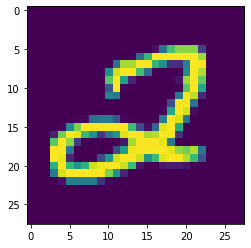

1


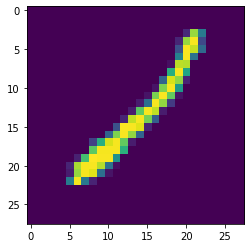

7


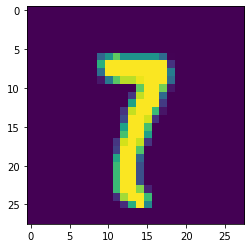

0


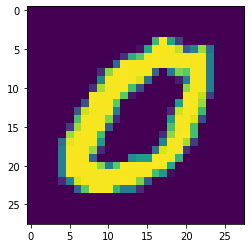

7


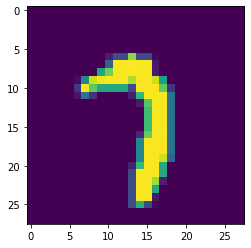

In [12]:
# Explore data
show5(train_dataloader)

## Build your Neural Network
Using the layers in `torch.nn` (which has been imported as `nn`) and the `torch.nn.functional` module (imported as `F`), construct a neural network based on the parameters of the dataset.
Use any architecture you like. 

*Note*: If you did not flatten your tensors in your transforms or as part of your preprocessing and you are using only `Linear` layers, make sure to use the `Flatten` layer in your network!

In [13]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten() 
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 532),     # The number of hidden neurons is choosen 2/3 the size of the input layer, plus the size of the output layer.
            nn.ReLU(),                 # level number is 1 to evoid network become to much specialize
            nn.Linear(532, 10),
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits




Specify a loss function and an optimizer, and instantiate the model.

If you use a less common loss function, please note why you chose that loss function in a comment.

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = NeuralNetwork().to(device)
criterion = nn.CrossEntropyLoss()   
optimizer = torch.optim.Adam(model.parameters(), lr = 1e-3)

## Running your Neural Network
Use whatever method you like to train your neural network, and ensure you record the average loss at each epoch. 
Don't forget to use `torch.device()` and the `.to()` method for both your model and your data if you are using GPU!

If you want to print your loss **during** each epoch, you can use the `enumerate` function and print the loss after a set number of batches. 250 batches works well for most people!

In [15]:
epochs = 100
patience = 5
counter = 0
best_val_loss = float("inf")



train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(epochs):
    epoch_num = epoch + 1
    #------TRAIN--------
    model.train()
    train_loss = 0.0
    for batch_idx, (x, y) in enumerate(train_dataloader):   # batch_idx: indice x:dati y:etichetta
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

        if batch_idx % 250 == 0:
            print(
                f"Epoch: {epoch_num}\n"
                f"Batch_idx: {batch_idx}\n"
                f"Train Loss: {loss.item():.4f}\n"
            )

    train_loss_epoch = train_loss / len(train_dataloader)
    train_losses.append( train_loss_epoch )

    #-----------VALIDATION------------
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in val_dataloader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            val_loss += criterion(out, y).item()
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)

    val_loss_epoch = val_loss / len(val_dataloader)
    accuracy_X_epoch = correct / total *100

    val_losses.append( val_loss_epoch)
    val_accuracies.append(accuracy_X_epoch)

    #print(
    #    f"Epoch: {epoch} |" 
    #    f"Train Loss: {train_loss_X_epoch:.4f} | "
    #    f"Val Loss: {val_loss_X_epoch:.4f} | "
    #    f"Val Acc: {accuracy_X_epoch:.2f}%"
    #)

    
    if  val_loss_epoch  < best_val_loss:
        best_val_loss = val_loss_epoch 
        torch.save(model.state_dict(), "best_model.pt")
        print(
                f"Epoch Best Model: {epoch_num} |" 
            )
    else:
        counter += 1
        if counter >= patience:
            print("Early point\n")
            print(
                f"Epoch: {epoch_num} |" 
                f"Train Loss: {train_loss_epoch:.4f} | "
                f"Val Loss: {val_loss_epoch:.4f} | "
                f"Val Acc: {accuracy_X_epoch:.2f}%"
            )

            break

print("Found model")

Epoch: 1
Batch_idx: 0
Train Loss: 2.3270

Epoch: 1
Batch_idx: 250
Train Loss: 0.3643

Epoch: 1
Batch_idx: 500
Train Loss: 0.2053

Epoch Best Model: 1 |
Epoch: 2
Batch_idx: 0
Train Loss: 0.1903

Epoch: 2
Batch_idx: 250
Train Loss: 0.2421

Epoch: 2
Batch_idx: 500
Train Loss: 0.1278

Epoch Best Model: 2 |
Epoch: 3
Batch_idx: 0
Train Loss: 0.0305

Epoch: 3
Batch_idx: 250
Train Loss: 0.0434

Epoch: 3
Batch_idx: 500
Train Loss: 0.0262

Epoch Best Model: 3 |
Epoch: 4
Batch_idx: 0
Train Loss: 0.1812

Epoch: 4
Batch_idx: 250
Train Loss: 0.1287

Epoch: 4
Batch_idx: 500
Train Loss: 0.1078

Epoch Best Model: 4 |
Epoch: 5
Batch_idx: 0
Train Loss: 0.0579

Epoch: 5
Batch_idx: 250
Train Loss: 0.0549

Epoch: 5
Batch_idx: 500
Train Loss: 0.0649

Epoch: 6
Batch_idx: 0
Train Loss: 0.0097

Epoch: 6
Batch_idx: 250
Train Loss: 0.0236

Epoch: 6
Batch_idx: 500
Train Loss: 0.0026

Epoch: 7
Batch_idx: 0
Train Loss: 0.0700

Epoch: 7
Batch_idx: 250
Train Loss: 0.0126

Epoch: 7
Batch_idx: 500
Train Loss: 0.0043

Ep

Plot the training loss (and validation loss/accuracy, if recorded).

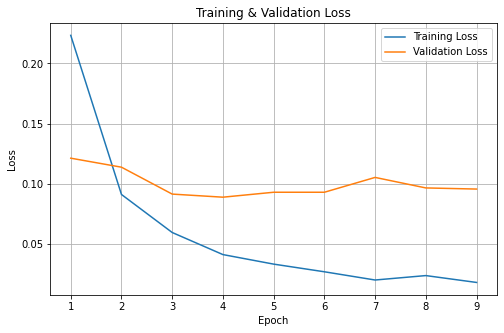

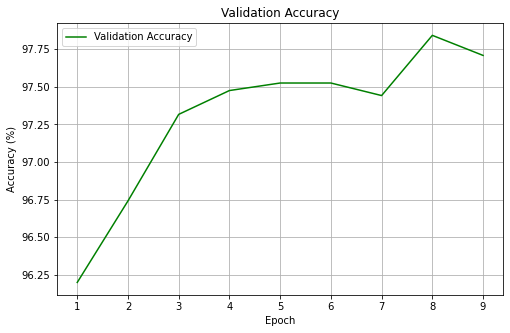

In [16]:
xepochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 5))
plt.plot(xepochs, train_losses, label="Training Loss")
plt.plot(xepochs, val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()
plt.grid(True)

plt.show()



plt.figure(figsize=(8, 5))
plt.plot(xepochs, val_accuracies, label="Validation Accuracy", color="green")

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

## Testing your model
Using the previously created `DataLoader` for the test set, compute the percentage of correct predictions using the highest probability prediction. 

If your accuracy is over 90%, great work, but see if you can push a bit further! 
If your accuracy is under 90%, you'll need to make improvements.
Go back and check your model architecture, loss function, and optimizer to make sure they're appropriate for an image classification task.

In [17]:
model.load_state_dict(torch.load("best_model.pt"))
model.eval()

correct = 0
total = 0
with torch.no_grad():
    for x, y in test_dataloader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)

  
    accuracy = correct / total *100
print(f"Test accuracy: {accuracy:.2f}%")

Test accuracy: 97.80%


## Improving your model

Once your model is done training, try tweaking your hyperparameters and training again below to improve your accuracy on the test set!

In [ ]:
import copy

# possible to improve performace using also CNN
def build_model(batch = 64,learning_rate = 1e-3, Nnode = 532, Level = False ):

    training_full = torchvision.datasets.MNIST(root='./data', train=True, download=True)

    # Create training, validation and test data from full dataset 80-20
    val_size = int(0.2* len(training_full))
    train_size = len(training_full)-val_size

    training_data, val_data = torch.utils.data.random_split(training_full, [train_size, val_size])
    data_training = training_full.data[training_data.indices].float() / 255.0
    train_mean = data_training.mean()
    train_std = data_training.std()

    data_val = training_full.data[val_data.indices].float() / 255.0
    val_mean = data_val.mean()
    val_std = data_val.std()

    # Define transforms for traning with augmentation and validation and test dataset wo
    transform_traning = transforms.Compose([
        transforms.RandomRotation(10), # adding data augumentation only in traning set to improve generalization of model. In particular is considered a small rotation of image. Small in order to evoid trasformation ex. u-> n with 180degree rotation
        transforms.ToTensor(),
        transforms.Normalize((train_mean ,), (train_std,))
    ])

    transform_validation = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((val_mean,), (val_std,))
    ])

    # remove augmentation for validation data set
    training_data.dataset.transform = transform_traning
    val_data.dataset.transform = transform_validation

    # Create test data
    test_data = torchvision.datasets.MNIST(
        root = "./data",
        train = False,
        download = True
    )

    transform_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((test_data.data.float().mean() / 255,), (test_data.data.float().std() / 255,))
    ])

    test_data.transform = transform_test
   
    train_dataloader = torch.utils.data.DataLoader(training_data, batch_size=64, shuffle=True)
    val_dataloader = torch.utils.data.DataLoader(val_data, batch_size=64, shuffle=True)
    test_dataloader = torch.utils.data.DataLoader(test_data, batch_size=64, shuffle=True)


    class NeuralNetwork(nn.Module):
        def __init__(self, Level):
            super().__init__()
            self.flatten = nn.Flatten()
            layers = [
                nn.Linear(28*28, Nnode),
                nn.ReLU()
            ]
            if Level:
                layers.append(nn.Linear(Nnode, Nnode))
                layers.append(nn.ReLU())
            layers.append(nn.Linear(Nnode, 10))
            self.linear_relu_stack = nn.Sequential(*layers)

        def forward(self, x):
            x = self.flatten(x)
            logits = self.linear_relu_stack(x)
            return logits



    
    
    optimizer = torch.optim.Adam(model.parameters(), lr = learning_rate)
    epochs = 100
    patience = 5
    counter = 0
    best_val_loss = float("inf")



    train_losses = []
    val_losses = []
    val_accuracies = []

    for epoch in range(epochs):
        epoch_num = epoch + 1
        #------TRAIN--------
        model.train()
        train_loss = 0.0
        for batch_idx, (x, y) in enumerate(train_dataloader):   # batch_idx: indice x:dati y:etichetta
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

           # if batch_idx % 250 == 0:
            #    print(
             #       f"Epoch: {epoch_num}\n"
            #        f"Batch_idx: {batch_idx}\n"
             #       f"Train Loss: {loss.item():.4f}\n"
             #   )

        train_loss_evarage_epoch = train_loss / len(train_dataloader)
        train_losses.append( train_loss_evarage_epoch )

        #-----------VALIDATION------------
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for x, y in val_dataloader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                val_loss += criterion(out, y).item()
                correct += (out.argmax(1) == y).sum().item()
                total += y.size(0)

        val_loss_avarage_epoch = val_loss / len(val_dataloader)
        accuracy_X_epoch = correct / total *100

        val_losses.append( val_loss_avarage_epoch)
        val_accuracies.append(accuracy_X_epoch)

        #print(
        #    f"Epoch: {epoch} |" 
        #    f"Train Loss: {train_loss_X_epoch:.4f} | "
        #    f"Val Loss: {val_loss_X_epoch:.4f} | "
        #    f"Val Acc: {accuracy_X_epoch:.2f}%"
        #)


        if  val_loss_avarage_epoch < best_val_loss:
            best_val_loss =  val_loss_avarage_epoch
            torch.save(model.state_dict(), "best_model.pt")
            best_model = copy.deepcopy(model)
        else:
            counter += 1
            if counter >= patience:
                print("Early point\n")
                print(
                    f"On validation dataset: |"
                    f"Epoch: {epoch} |" 
                    f"Train Loss: {train_loss_evarage_epoch:.4f} | "
                    f"Val Loss: {val_loss_avarage_epoch:.4f} | "
                    f"Val Acc: {accuracy_X_epoch:.2f}%"
                )

                break

    print("Found model")

    model.load_state_dict(torch.load("best_model.pt"))
    model.eval()

    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in test_dataloader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                correct += (out.argmax(1) == y).sum().item()
                total += y.size(0)


        accuracy = correct / total *100
        print(f"Test accuracy: {accuracy:.2f}%")
    return best_model
        
model = build_model(batch = 54 ,learning_rate =1e-4, Nnode = 512, Level = True ) 

        
        

## Saving your model
Using `torch.save`, save your model for future loading.

In [11]:
torch.save(model.state_dict(), "model.pt")
